In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.shape

(7043, 21)

In [7]:
df=df.drop("customerID",axis=1)

In [8]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


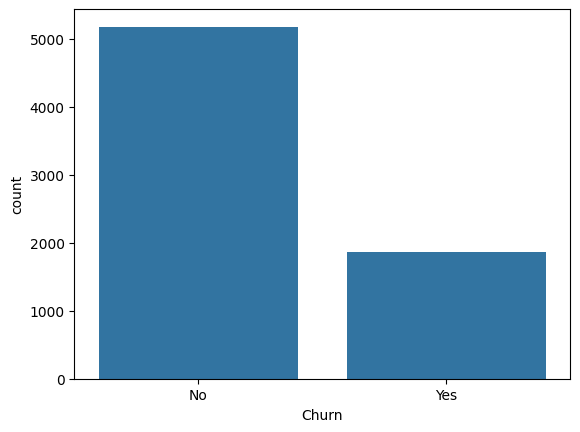

In [9]:
sns.countplot(x="Churn", data=df)
plt.show()

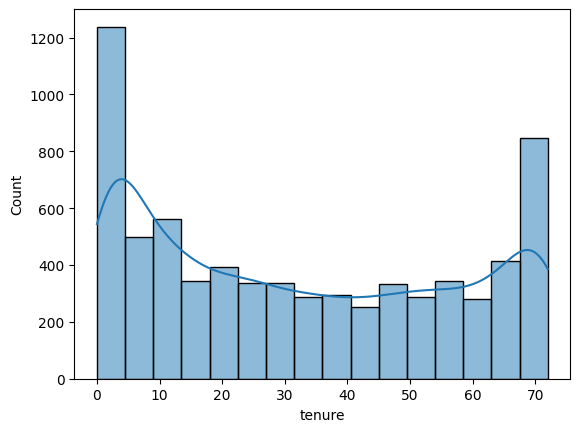

In [10]:
sns.histplot(df["tenure"], kde=True)
plt.show()

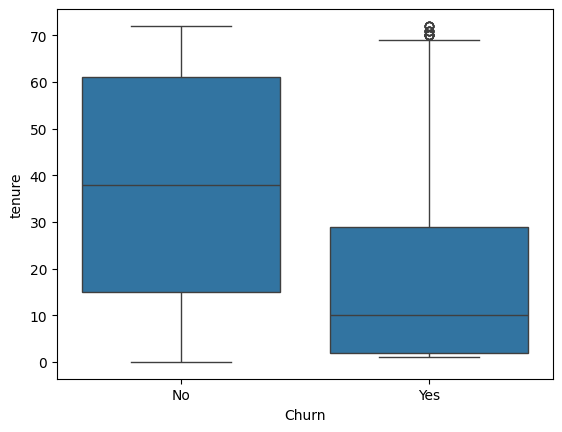

In [11]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

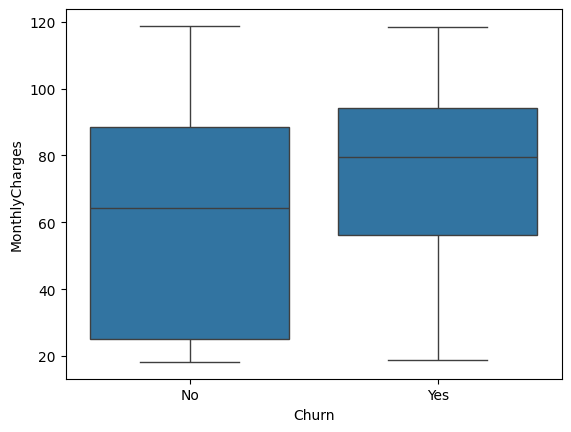

In [12]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

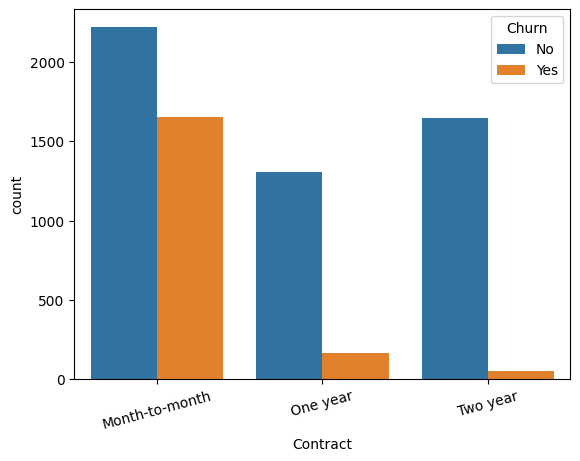

In [13]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=15)
plt.show()

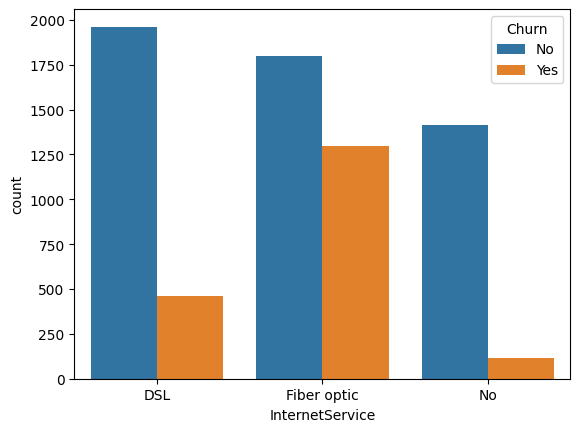

In [14]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.show()

In [15]:
service_cols = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]
for col in service_cols:
    
    df[col] = df[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

In [16]:
for col in service_cols:
    print(col ,"==",df[col].unique())

MultipleLines == <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
OnlineSecurity == <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
OnlineBackup == <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
DeviceProtection == <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
TechSupport == <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingTV == <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingMovies == <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [17]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder();
for col in service_cols:
    df[col] = le.fit_transform(df[col])

In [18]:
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [19]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.5,0
2,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [20]:
col=df.columns
col

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [21]:
for cols in col:
    print(cols,"==",df[cols].unique() )

gender == [0 1]
SeniorCitizen == [0 1]
Partner == [1 0]
Dependents == [0 1]
tenure == [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService == [0 1]
MultipleLines == [0 1]
InternetService == <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity == [0 1]
OnlineBackup == [1 0]
DeviceProtection == [0 1]
TechSupport == [0 1]
StreamingTV == [0 1]
StreamingMovies == [0 1]
Contract == <ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
PaperlessBilling == [1 0]
PaymentMethod == <ArrowStringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str
MonthlyCharges == [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges == <ArrowStringArray>
[  '29.85',  '1889.5',  

In [22]:
cate_col=["InternetService","Contract","PaymentMethod"]
df = pd.get_dummies(
    df,
    columns=cate_col,
    drop_first=True
)

In [23]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.5,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


In [24]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)
X = df.drop("Churn", axis=1)

y=df["Churn"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42,stratify=y)

In [26]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  StreamingTV    

In [29]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

In [30]:
for col in num_cols:
    a=df[col].isna().sum()
    if(a!=0):
        df[col] = df["TotalCharges"].fillna(
    df[col].median()
)


In [31]:
df["TotalCharges"].dtype

dtype('float64')

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [33]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test[num_cols] = scaler.transform(X_test[num_cols])

ValueError: could not convert string to float: ' '

In [36]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [38]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test[num_cols] = scaler.transform(X_test[num_cols])

In [46]:
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [41]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [45]:
import joblib

joblib.dump(model, "../models/logistic_model.pkl")

['../models/logistic_model.pkl']

In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.8055358410220014


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[927 108]
 [166 208]]


In [52]:
from sklearn.tree import DecisionTreeClassifier
model_tree=DecisionTreeClassifier(random_state=0)
model_tree.fit(X_train,y_train)
y_pred_tree=model.predict(X_test)
acc2=accuracy_score(y_test,y_pred)
print(acc2)

0.8055358410220014


In [48]:
cm = confusion_matrix(y_test, y_pred_tree)

print(cm)

[[927 108]
 [166 208]]


In [50]:
cm1=classification_report(y_test,y_pred)
print(cm1)

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
acc1=accuracy_score(y_test,rf_pred)
print(acc1)

0.7877927608232789
